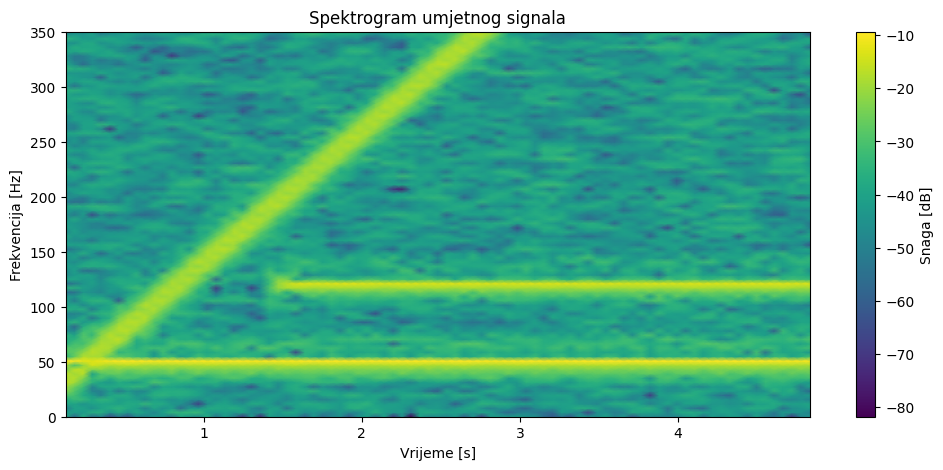

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

fs = 1000
trajanje = 5

t = np.linspace(0, trajanje, fs * trajanje, endpoint=False)

# stabilna frekvencija od 50 Hz
signal1 = np.sin(2 * np.pi * 50 * t)

# STabilna f od 120 Hz, ali dolazi kasnije
signal2 = np.zeros_like(t)
mask = t > 1.5
signal2[mask] = 0.7 * np.sin(2 * np.pi * 120 * t[mask])

# F koja raste kroz vrijeme od 20 do 300 Hz
frekvencija = 20 + 60 * t
signal3 = 0.8 * np.sin(2 * np.pi * frekvencija * t)

# dodavanje suma
sum = 0.2 * np.random.randn(len(t))

# i ovo je neki konacni signal
signal = signal1 + signal2 + signal3 + sum


f, vrijeme, Sxx = spectrogram(signal,fs=fs,nperseg=256,noverlap=200)

plt.figure(figsize=(12, 5))
plt.pcolormesh(vrijeme,f,10 * np.log10(Sxx),shading="gouraud")
plt.colorbar(label="Snaga [dB]")
plt.xlabel("Vrijeme [s]")
plt.ylabel("Frekvencija [Hz]")
plt.title("Spektrogram umjetnog signala")
plt.ylim(0, 350)
plt.show()